<a href="https://colab.research.google.com/github/georgemulu/analystlab-internship/blob/main/Online_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Understanding

In [ ]:
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


**Number of rows and columns**

In [ ]:
df.shape

(541909, 8)

**Datatypes of all columns**

In [ ]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


Numerical features

In [ ]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['Quantity', 'UnitPrice', 'CustomerID'], dtype='object')

Categorical features

In [ ]:
df.select_dtypes(include=['object']).columns

Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object')

There is no column that has unique values

This dataset contains sales data made to customers

# Data Cleaning

## Missing Values

In [ ]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Description has 1454 missing values while CustomerID has 135080

In [ ]:
df[df['CustomerID'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom


I have chosen forward fill for missing values in the customerID column since all missing values occur within the same invoiceNo and the records are arranged by customerID

In [ ]:
df['CustomerID'] = df['CustomerID'].ffill()

In [ ]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
df[df['Description'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,17920.0,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,17841.0,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,17841.0,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,17841.0,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,12472.0,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,12/7/2011 18:26,0.0,12935.0,United Kingdom
535326,581203,23406,NaN,15,12/7/2011 18:31,0.0,12935.0,United Kingdom
535332,581209,21620,NaN,6,12/7/2011 18:35,0.0,12935.0,United Kingdom
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,13436.0,United Kingdom


In [ ]:
df[df['StockCode'] == '22139']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
106,536381,22139,RETROSPOT TEA SET CERAMIC 11 PC,23,12/1/2010 9:41,4.25,15311.0,United Kingdom
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,17920.0,United Kingdom
6392,536942,22139,amazon,15,12/3/2010 12:08,0.00,14680.0,United Kingdom
6885,536982,22139,RETROSPOT TEA SET CERAMIC 11 PC,10,12/3/2010 14:27,11.02,14723.0,United Kingdom
7203,537011,22139,NaN,-5,12/3/2010 15:38,0.00,14898.0,United Kingdom
...,...,...,...,...,...,...,...,...
538411,581405,22139,RETROSPOT TEA SET CERAMIC 11 PC,1,12/8/2011 13:50,4.95,13521.0,United Kingdom
539531,581439,22139,RETROSPOT TEA SET CERAMIC 11 PC,1,12/8/2011 16:30,10.79,12955.0,United Kingdom
540441,581486,22139,RETROSPOT TEA SET CERAMIC 11 PC,6,12/9/2011 9:38,4.95,17001.0,United Kingdom
541387,581498,22139,RETROSPOT TEA SET CERAMIC 11 PC,2,12/9/2011 10:26,10.79,16558.0,United Kingdom


As you can see above from a sample StockCode, Items with the same StockCode tend to have a similar description for the products.

I will therefore sort the dataset by StockCode in ascending order and fill the missing values using forward fill

In [ ]:
sorted_df = df.sort_values(by='StockCode',ascending=True)

In [ ]:
sorted_df['Description'] = sorted_df['Description'].ffill()

In [ ]:
sorted_df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


## Duplicated Records

In [ ]:
sorted_df[sorted_df.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
139262,548309,10120,DOGGY RUBBER,1,3/30/2011 12:02,0.21,16657.0,United Kingdom
248501,558860,10125,MINI FUNKY DESIGN TAPES,1,7/4/2011 12:18,0.85,17975.0,United Kingdom
308705,564049,10133,COLOURING PENCILS BROWN TUBE,10,8/22/2011 13:30,0.42,17585.0,United Kingdom
239419,558049,10133,COLOURING PENCILS BROWN TUBE,1,6/24/2011 14:16,0.42,15850.0,United Kingdom
396055,571054,10135,COLOURING PENCILS BROWN TUBE,1,10/13/2011 13:58,1.25,14234.0,United Kingdom
...,...,...,...,...,...,...,...,...
414142,572344,M,Manual,48,10/24/2011 10:43,1.50,14607.0,United Kingdom
414141,572344,M,Manual,48,10/24/2011 10:43,1.50,14607.0,United Kingdom
414140,572344,M,Manual,48,10/24/2011 10:43,1.50,14607.0,United Kingdom
414139,572344,M,Manual,48,10/24/2011 10:43,1.50,14607.0,United Kingdom


In [ ]:
sorted_df.drop_duplicates(inplace=True)

In [ ]:
duplicates_removed = df.shape[0]-sorted_df.shape[0]
duplicates_removed

5268

##Standardization

Converted InvoiceDate to Datetime datatype

In [ ]:
sorted_df['InvoiceDate'] = pd.to_datetime(sorted_df['InvoiceDate'], errors='coerce')

In [ ]:
sorted_df['InvoiceDate'].sample(10)

,InvoiceDate
102196,2011-02-25 11:53:00
317072,2011-08-30 10:36:00
270427,2011-07-19 13:57:00
218595,2011-06-08 13:35:00
347614,2011-09-19 14:23:00
349207,2011-09-20 13:42:00
91680,2011-02-16 11:37:00
228254,2011-06-15 13:37:00
517423,2011-12-01 13:08:00
192291,2011-05-16 16:48:00


All InvoiceDates have same format

In [ ]:
sorted_df['Description'] = sorted_df['Description'].str.upper()

In [ ]:
sorted_df['Description'].sample(5)

,Description
154680,CARD BILLBOARD FONT
478994,PINK HEART SHAPE LOVE BUCKET
166521,ANTIQUE SILVER T-LIGHT GLASS
298610,200 RED + WHITE BENDY STRAWS
351340,JUMBO BAG VINTAGE CHRISTMAS


In [ ]:
sorted_df['Country'].unique()

array(['United Kingdom', 'Switzerland', 'France', 'Spain', 'EIRE',
       'Germany', 'Japan', 'Portugal', 'Canada', 'Israel', 'Norway',
       'Unspecified', 'Greece', 'Sweden', 'Denmark', 'Netherlands',
       'Italy', 'Australia', 'Belgium', 'Brazil', 'Poland', 'Austria',
       'Finland', 'Lithuania', 'Cyprus', 'Iceland', 'USA',
       'Channel Islands', 'Hong Kong', 'RSA', 'Singapore', 'Saudi Arabia',
       'United Arab Emirates', 'Czech Republic', 'Malta',
       'European Community', 'Lebanon', 'Bahrain'], dtype=object)

In [ ]:
sorted_df['CustomerID'] = sorted_df['CustomerID'].astype(str)
sorted_df['CustomerID'] = sorted_df['CustomerID'].str.replace('.0', '', regex=False)

## Data Validation

In [ ]:
sorted_df[sorted_df['Quantity']<= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
171573,551429,10002,INFLATABLE POLITICAL GLOBE,-3,2011-04-28 15:05:00,0.00,13499.0,United Kingdom
265293,560213,10123C,HEARTS WRAPPING TAPE,-18,2011-07-15 15:05:00,0.00,14722.0,United Kingdom
150159,549349,10123G,HEARTS WRAPPING TAPE,-38,2011-04-08 11:13:00,0.00,12717.0,United Kingdom
474647,576843,10133,DAMAGED,-82,2011-11-16 15:32:00,0.00,13599.0,United Kingdom
246756,C558716,10133,COLOURING PENCILS BROWN TUBE,-10,2011-07-01 13:22:00,0.42,17888.0,United Kingdom
...,...,...,...,...,...,...,...,...
96690,C544580,S,SAMPLES,-1,2011-02-21 14:25:00,7.00,12365.0,United Kingdom
96689,C544580,S,SAMPLES,-1,2011-02-21 14:25:00,5.44,12365.0,United Kingdom
96713,C544583,S,SAMPLES,-1,2011-02-21 14:48:00,4.59,13410.0,United Kingdom
96714,C544583,S,SAMPLES,-1,2011-02-21 14:48:00,95.00,13410.0,United Kingdom


10587 rows have a negative quantity value. We will drop them since we have no context whether they were returns or cancellations.

In [ ]:
sorted_df = sorted_df[sorted_df['Quantity']>0]

In [ ]:
sorted_df[sorted_df['UnitPrice'] <= 0.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
139083,548286,10002,INFLATABLE POLITICAL GLOBE,180,2011-03-30 11:47:00,0.0,17863.0,United Kingdom
454350,575518,10080,CHECK,22,2011-11-10 10:53:00,0.0,14562.0,United Kingdom
279310,561271,10080,GROOVY CACTUS INFLATABLE,170,2011-07-26 12:18:00,0.0,12584.0,United Kingdom
140286,548399,15030,FAN BLACK FRAME,150,2011-03-30 17:25:00,0.0,18075.0,United Kingdom
108588,545551,15058A,BLUE POLKADOT GARDEN PARASOL,20,2011-03-03 15:11:00,0.0,18041.0,United Kingdom
...,...,...,...,...,...,...,...,...
326552,565556,POST,POSTAGE,750,2011-09-05 12:14:00,0.0,16820.0,United Kingdom
52262,540699,POST,POSTAGE,1000,2011-01-11 09:32:00,0.0,17450.0,United Kingdom
317501,564762,gift_0001_10,DOTCOMGIFTSHOP GIFT VOUCHER £10.00,30,2011-08-30 10:48:00,0.0,14911.0,United Kingdom
228807,556955,gift_0001_20,TO PUSH ORDER THROUGHA S STOCK WAS,10,2011-06-16 09:04:00,0.0,15585.0,United Kingdom


In [ ]:
sorted_df[sorted_df['StockCode'] == 'POST']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
491981,578084,POST,POSTAGE,2,2011-11-22 16:34:00,15.0,12465.0,Belgium
516548,579927,POST,POSTAGE,3,2011-12-01 09:20:00,18.0,12572.0,Germany
103055,545051,POST,POSTAGE,1,2011-02-27 11:58:00,18.0,12599.0,France
359187,568179,POST,POSTAGE,3,2011-09-25 13:39:00,28.0,12545.0,Spain
217727,555931,POST,POSTAGE,4,2011-06-08 08:31:00,40.0,17828.0,Malta
...,...,...,...,...,...,...,...,...
392929,570754,POST,POSTAGE,1,2011-10-12 11:40:00,18.0,12633.0,Germany
457126,575732,POST,POSTAGE,2,2011-11-11 08:19:00,18.0,12712.0,Germany
266886,560272,POST,POSTAGE,1,2011-07-17 14:56:00,18.0,12691.0,France
34099,539318,POST,POSTAGE,6,2010-12-16 19:09:00,40.0,12348.0,Finland


1176 rows have unit price of 0 or below. We will drop them since as you can see from a sample product above, a product might have a different unitprice across rows.

In [ ]:
sorted_df = sorted_df[sorted_df['UnitPrice']>0]

In [ ]:
summary = [
    {"Issue Found":"Missing Values", "Action Taken": "Filled"},
    {"Issue Found":"Duplicates","Action Taken":"Removed"},
    {"Issue Found":"Standardization","Action Taken":"Applied"},
    {"Issue Found":"Invalid Entries","Action Taken":"Corrected"}
]
summary_df = pd.DataFrame(summary)
summary_df

,Issue Found,Action Taken
0,Missing Values,Filled
1,Duplicates,Removed
2,Standardization,Applied
3,Invalid Entries,Corrected


# Exploratory Data Analysis

In [ ]:
sorted_df['Total Cost'] = sorted_df['Quantity'] * sorted_df['UnitPrice']

In [ ]:
sorted_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Total Cost
count,524878.000000,524878,524878.000000,524878.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317048576,3.922573,15273.515280,20.275399
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,1.000000,2011-03-28 12:13:00,1.250000,13798.000000,3.900000
50%,4.000000,2011-07-20 11:22:00,2.080000,15145.000000,9.920000
75%,11.000000,2011-10-19 11:41:00,4.130000,16805.000000,17.700000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000
std,156.280031,NaN,36.093028,1738.022572,271.693566


## Top 10 revenue generating countries

In [ ]:
top_10_countries = sorted_df.groupby('Country')['Total Cost'].sum().sort_values(ascending=False).head(10)
top_10_countries

,Total Cost
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


## Customer distribution across countries

In [ ]:
customer_count = sorted_df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False).head(10)
customer_count

,CustomerID
Country,
United Kingdom,4012
Germany,94
France,90
Spain,30
Belgium,25
Switzerland,24
EIRE,23
Portugal,20
Italy,14


## Monthly sales trend

In [ ]:
sorted_df['Invoice month'] = sorted_df['InvoiceDate'].dt.month
sales_by_month = sorted_df.groupby('Invoice month')['Total Cost'].sum()
sales_by_month

,Total Cost
Invoice month,
1,689811.610
2,522545.560
3,716215.260
4,536968.491
5,769296.610
6,760547.010
7,718076.121
8,757841.380
9,1056435.192


## Top selling product

In [ ]:
sales_by_product = sorted_df.groupby('StockCode')['Total Cost'].sum().sort_values(ascending=False).head(10)
sales_by_product.idxmax()

'DOT'

## Most purchased products

In [ ]:
purchased_products = sorted_df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(10)
purchased_products

,Quantity
StockCode,
23843,80995
23166,78033
22197,56898
84077,54951
85099B,48371
85123A,37641
21212,36396
84879,36362
23084,30739


## Top 10 customers by Total Sales

In [ ]:
customer_revenue = sorted_df.groupby('CustomerID')['Total Cost'].sum().sort_values(ascending=False).head(10)
customer_revenue

,Total Cost
CustomerID,
14646,282777.64
18102,275609.41
17450,194432.39
16446,168472.50
14911,158806.24
14156,130161.32
12415,125798.47
17511,97537.43
16029,81455.21


# Data Visualization

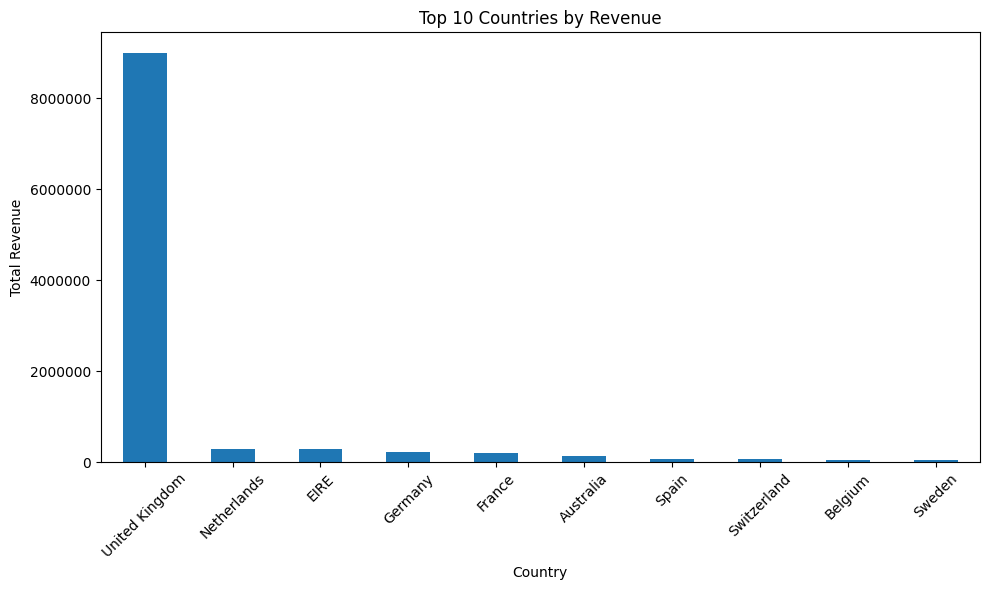

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
top_10_countries.plot(kind='bar', ax=ax)

ax.set_title('Top 10 Countries by Revenue')
ax.set_xlabel('Country')
ax.set_ylabel('Total Revenue')
ax.ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This bar chart displays the top 10 countries by total revenue generated. It clearly shows that the United Kingdom contributes the vast majority of the revenue compared to other countries, followed by the Netherlands and EIRE.

Text(0, 0.5, 'Country')

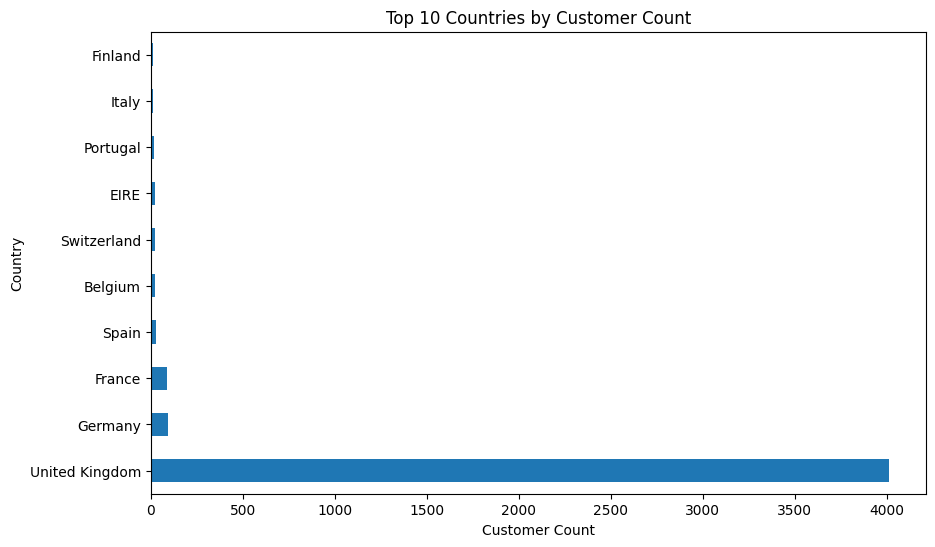

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
customer_count.plot(kind='barh', ax=ax)

ax.set_title('Top 10 Countries by Customer Count')
ax.set_xlabel('Customer Count')
ax.set_ylabel('Country')

This horizontal bar chart illustrates the top 10 countries based on their unique customer count. Similar to revenue, the United Kingdom has a significantly higher number of customers than any other country, with Germany and France following distantly.

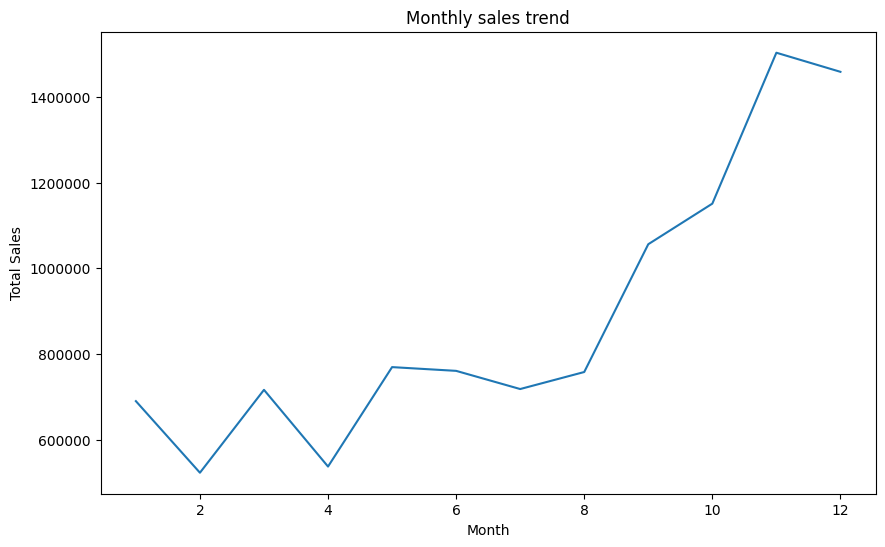

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sales_by_month.plot(kind='line', ax=ax)

ax.set_title('Monthly sales trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')
ax.ticklabel_format(style='plain', axis='y')

This line chart shows the monthly sales trend over the year. There's a clear upward trend towards the end of the year, with a significant peak in November and December, likely indicating holiday shopping. Sales are generally lower in the early months of the year.

Text(0, 0.5, 'Total Sales')

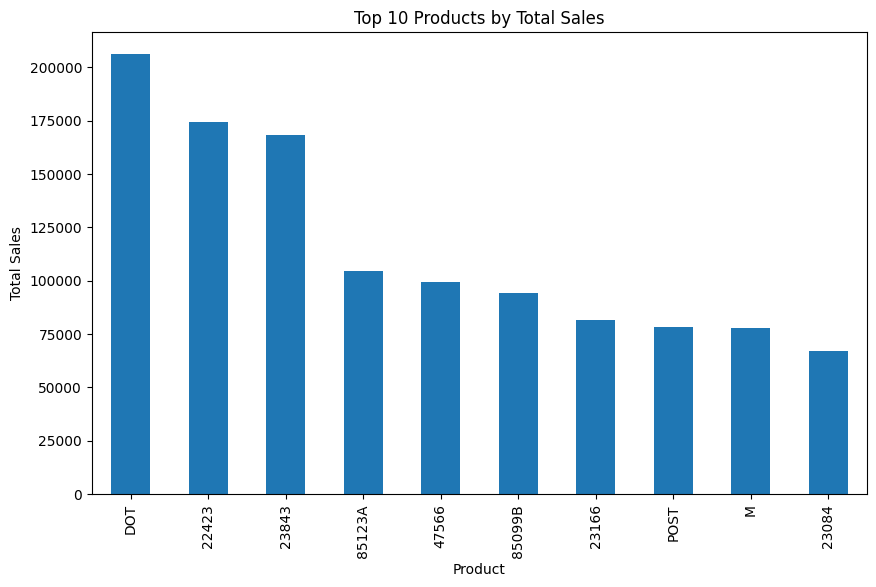

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sales_by_product.plot(kind='bar', ax=ax)

ax.set_title('Top 10 Products by Total Sales')
ax.set_xlabel('Product')
ax.set_ylabel('Total Sales')

This bar chart presents the top 10 products by their total sales (revenue). Product 'DOT' leads significantly in total sales, indicating it's a high-value item or sold in large quantities, followed by '22423' and '23843'.

Text(0, 0.5, 'Quantity Purchased')

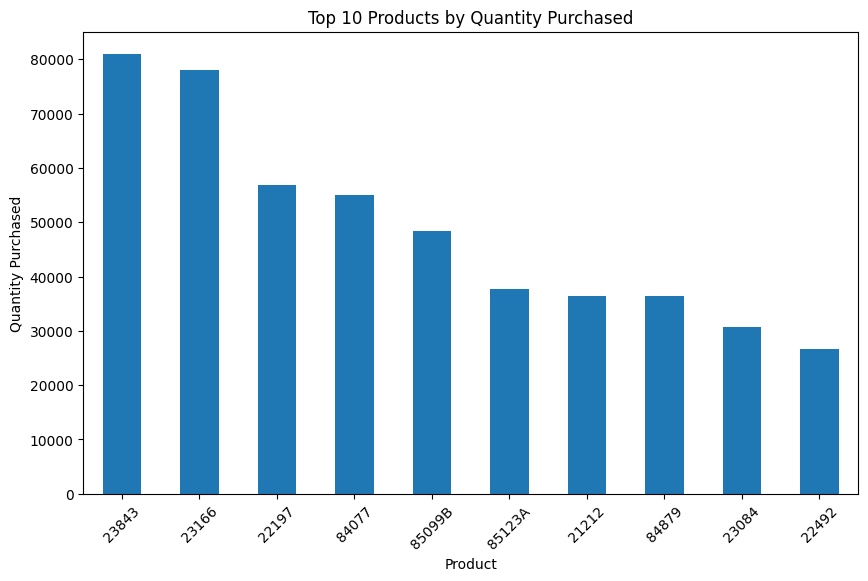

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
purchased_products.plot(kind='bar', ax=ax)

ax.set_title('Top 10 Products by Quantity Purchased')
ax.set_xlabel('Product')
ax.set_xticklabels(purchased_products.index, rotation=45)
ax.set_ylabel('Quantity Purchased')

This bar chart illustrates the top 10 products by the total quantity purchased. Product '23843' and '23166' are the most frequently purchased items, indicating their popularity or common use among customers. The ranking here differs slightly from the top products by total sales, suggesting some popular items might have lower unit prices.

Text(0, 0.5, 'Total Sales')

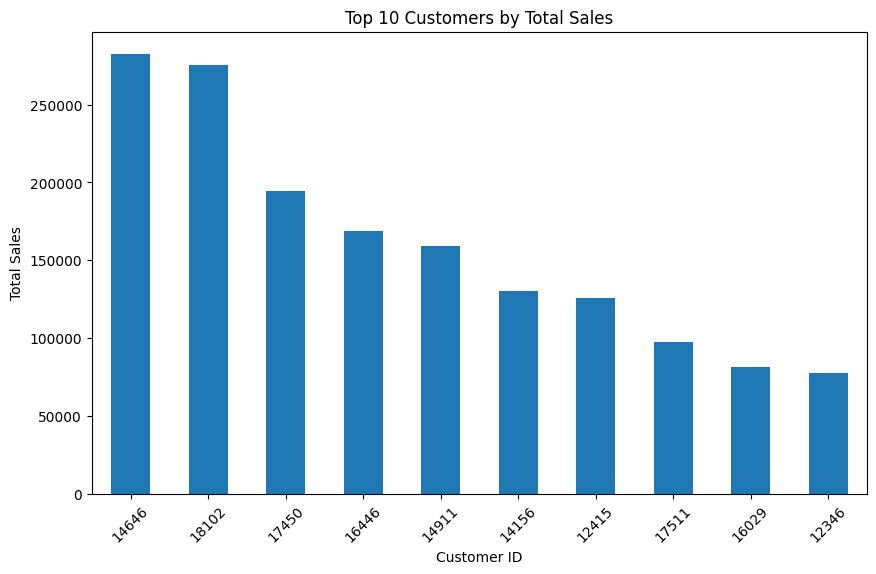

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
customer_revenue.plot(kind='bar', ax=ax)

ax.set_title('Top 10 Customers by Total Sales')
ax.set_xlabel('Customer ID')
ax.set_xticklabels(customer_revenue.index, rotation=45)
ax.set_ylabel('Total Sales')

This bar chart displays the top 10 customers ranked by their total sales contribution. Customer ID '14646' and '18102' are the highest revenue-generating customers, highlighting their importance to the business. This information can be valuable for customer segmentation and targeted marketing efforts.

## Key Insights from the Dataset

### 1. Dominance of the United Kingdom in Sales and Customer Base

**Analysis:** The 'Top 10 Countries by Revenue' bar chart clearly shows that the United Kingdom generates a significantly higher revenue compared to all other countries. Similarly, the 'Top 10 Countries by Customer Count reveals that the UK also has a vastly larger customer base.

**Insight:** The business is heavily reliant on the UK market, both in terms of sales volume and customer acquisition. This suggests that while the UK is a strong foundation, there's significant potential for growth in other international markets, which currently contribute a much smaller fraction of the total revenue and customer count.

### 2. Strong Seasonal Sales Trend Towards Year-End

**Analysis:** The 'Monthly sales trend' line chart  illustrates a clear upward trajectory in sales from September to November, with December maintaining high sales before a dip in the new year. This indicates strong seasonality.

**Insight:** Sales peak significantly towards the end of the year, likely driven by holiday shopping (e.g., Black Friday, Christmas). This pattern can be leveraged for strategic planning of inventory, marketing campaigns, and staffing to maximize revenue during these peak periods. Conversely, the lower sales in the early months of the year might require specific promotional strategies.

### 3. Distinction Between High-Revenue and High-Quantity Products

**Analysis:** By comparing the 'Top 10 Products by Total Sales'  and 'Top 10 Products by Quantity Purchased' , we observe that while some products appear in both lists (e.g., '23843'), their rankings can differ. For instance, 'DOT' leads in total sales but isn't as high in quantity purchased, suggesting it's a high-value item. Conversely, some products are purchased in high quantities but contribute less to overall revenue, implying lower unit prices.

**Insight:** The product catalog includes both high-value items that drive significant revenue per unit and high-volume items that are frequently purchased. This dual nature allows for different sales strategies: promoting high-value items for increased profitability per transaction and ensuring ample stock and easy accessibility for high-volume, popular items to maintain customer satisfaction and repeat purchases.

### 4. Identification of High-Value Customers

**Analysis:** The 'Top 10 Customers by Total Sales' bar chart  highlights specific customer IDs (e.g., '14646', '18102', '17450') who contribute a substantial amount to the total sales.

**Insight:** A small number of customers are responsible for a significant portion of the company's revenue. These high-value customers are crucial for business success. Implementing a customer loyalty program, personalized offers, and dedicated support for these key accounts could further enhance their lifetime value and encourage continued spending.

In [ ]:
from google.colab import files
df.to_csv('Online_retail_cleaned',index=False)
files.download('Online_retail_cleaned')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>